In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
import xgboost as xgb
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor, XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('games.csv')

In [3]:
df.head(5)

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB


In [5]:
df.duplicated().sum()

429

In [6]:
df= df.drop_duplicates()

In [7]:
df['rated'] = df['rated'].astype(int)

In [8]:
df['created_at'] = pd.to_datetime(df['created_at'], unit='ms')
df['last_move_at'] = pd.to_datetime(df['last_move_at'], unit='ms')

In [9]:
df[['base_time_min', 'increment_sec']] = df['increment_code'].str.split('+', expand=True)
df['base_time_min'] = pd.to_numeric(df['base_time_min'])
df['increment_sec'] = pd.to_numeric(df['increment_sec'])

In [10]:
df = df.drop(['increment_code'], axis=1)
df = df.drop(['id'], axis=1)
df = df.drop(['white_id', 'black_id'], axis=1)

In [11]:
anomalies = (
    (df['turns'] > 200) |  # длинные партии
    ((df['base_time_min'] < 3) & (df['turns'] > 100)) |  # быстрые с >100 ходов
    ((df['base_time_min'] > 30) & (df['turns'] < 20))  # медленные с <20 ходов
)

df = df[~anomalies].copy()

In [12]:
long_games = df[df['turns'] > 200]
print(f"Партий с >200 ходов: {len(long_games)}")

fast_long = df[(df['base_time_min'] < 3) & (df['turns'] > 100)]
print(f"Быстрые партии (<3 мин) с >100 ходов: {len(fast_long)}")

slow_short = df[(df['base_time_min'] > 30) & (df['turns'] < 20)]
print(f"Медленные партии (>30 мин) с <20 ходов: {len(slow_short)}")

Партий с >200 ходов: 0
Быстрые партии (<3 мин) с >100 ходов: 0
Медленные партии (>30 мин) с <20 ходов: 0


In [13]:
df

,rated,created_at,last_move_at,turns,victory_status,winner,white_rating,black_rating,moves,opening_eco,opening_name,opening_ply,base_time_min,increment_sec
0,0,2017-08-31 20:06:40.000,2017-08-31 20:06:40.000,13,outoftime,white,1500,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5,15,2
1,1,2017-08-30 21:53:20.000,2017-08-30 21:53:20.000,16,resign,black,1322,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4,5,10
2,1,2017-08-30 21:53:20.000,2017-08-30 21:53:20.000,61,mate,white,1496,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3,5,10
3,1,2017-08-30 16:20:00.000,2017-08-30 16:20:00.000,61,mate,white,1439,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3,20,0
4,1,2017-08-29 18:06:40.000,2017-08-29 18:06:40.000,95,mate,white,1523,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5,30,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,1,2017-07-11 16:35:14.342,2017-07-11 16:40:36.076,24,resign,white,1691,1220,d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...,A80,Dutch Defense,2,10,10
20054,1,2017-07-10 14:48:09.760,2017-07-10 15:00:33.979,82,mate,black,1233,1196,d4 d6 Bf4 e5 Bg3 Nf6 e3 exd4 exd4 d5 c3 Bd6 Bd...,A41,Queen's Pawn,2,10,0
20055,1,2017-07-10 14:44:37.493,2017-07-10 14:47:30.327,35,mate,white,1219,1286,d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...,D00,Queen's Pawn Game: Mason Attack,3,10,0
20056,1,2017-07-10 14:15:27.019,2017-07-10 14:31:13.718,109,resign,white,1360,1227,e4 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Nd5 c4 Nb...,B07,Pirc Defense,4,10,0


In [14]:
corr = df[['rated','turns','white_rating','black_rating','opening_ply','base_time_min','increment_sec']].corr()

In [15]:
corr

,rated,turns,white_rating,black_rating,opening_ply,base_time_min,increment_sec
rated,1.000000,0.084721,0.003450,0.031692,-0.004350,-0.107905,-0.104113
turns,0.084721,1.000000,0.124380,0.155493,0.050172,-0.004355,-0.027952
white_rating,0.003450,0.124380,1.000000,0.632663,0.277105,-0.047734,-0.001011
black_rating,0.031692,0.155493,0.632663,1.000000,0.253390,-0.055519,-0.010999
opening_ply,-0.004350,0.050172,0.277105,0.253390,1.000000,-0.008240,0.008182
base_time_min,-0.107905,-0.004355,-0.047734,-0.055519,-0.008240,1.000000,0.392904
increment_sec,-0.104113,-0.027952,-0.001011,-0.010999,0.008182,0.392904,1.000000


<Axes: >

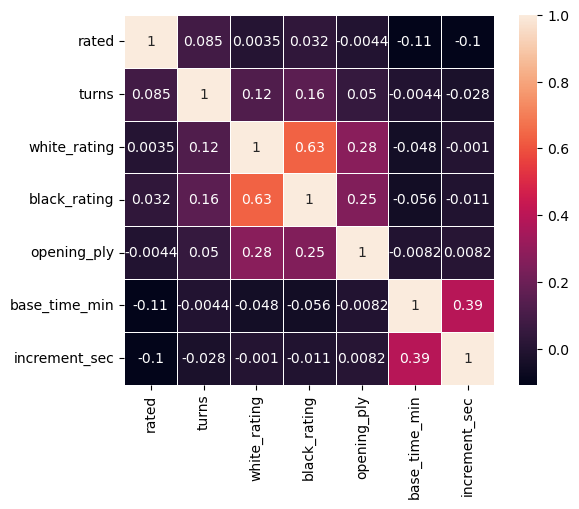

In [16]:
sns.heatmap(corr, square=True, annot=True, linewidths=.5)

In [17]:
victorys = {'mate': 0,'resign': 1, 'outoftime': 2,'draw': 3}

df_mod = df.copy()
df_mod['victory_status'] = df_mod['victory_status'].map(victorys)

In [18]:
df['winner'].value_counts()

winner
white    9726
black    8876
draw      892
Name: count, dtype: int64

In [19]:
wh_and_bl = {'white': 0,'black': 1,'draw': 2}

df_mod['winner'] = df_mod['winner'].map(wh_and_bl)

In [20]:
df_mod['rating_diff'] = df_mod['white_rating'] - df_mod['black_rating']
df_mod['abs_rating_diff'] = abs(df_mod['rating_diff'])
df_mod['avg_rating'] = (df_mod['white_rating'] + df_mod['black_rating']) / 2
df_mod['total_time'] = df_mod['base_time_min'] + df_mod['increment_sec'] * 40

In [21]:
futed = ['rated', 'white_rating', 'black_rating', 'opening_ply', 'base_time_min', 'increment_sec', 
         'victory_status','winner','rating_diff','abs_rating_diff','avg_rating','total_time']
X = df_mod[futed]
y = df_mod['turns']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## XGRegressor

In [23]:
model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

In [24]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [25]:
y_pred = model.predict(X_test)

In [26]:
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

Результаты XGBoost регрессии:
MAE: 23.76
MSE: 913.79
RMSE: 30.23
R²: 0.1306


## Bagging

In [27]:
bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [28]:
bag_model.fit(X_train, y_train)

,estimator,DecisionTreeR...r(max_depth=5)
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [29]:
y_pred = bag_model.predict(X_test)

In [30]:
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

MAE: 23.80
MSE: 922.92
RMSE: 30.38
R²: 0.1220


In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import regularizers

In [32]:
y_train_log = np.log1p(y_train) 
y_test_log = np.log1p(y_test)

In [33]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

In [34]:
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [35]:
y_train_scaled = scaler_y.fit_transform(y_train_log.values.reshape(-1, 1)).flatten()

In [36]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.1),
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.1),
    
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [37]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               3328      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                        

In [38]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

In [39]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

In [40]:
sample_size = int(0.7 * len(X_train))
indices = np.random.choice(len(X_train), sample_size, replace=False)

X_train_small = X_train_scaled[indices]
y_train_small = y_train_scaled[indices]

In [41]:
history = model.fit(
    X_train_small,  
    y_train_small, 
    epochs=25,      
    batch_size=1024,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
9/9 [==============================] - 1s 25ms/step - loss: 1.2315 - mae: 0.8303 - val_loss: 0.8762 - val_mae: 0.6926
Epoch 2/25
9/9 [==============================] - 0s 7ms/step - loss: 1.0223 - mae: 0.7630 - val_loss: 0.8807 - val_mae: 0.6968
Epoch 3/25
9/9 [==============================] - 0s 8ms/step - loss: 0.9575 - mae: 0.7336 - val_loss: 0.8745 - val_mae: 0.6932
Epoch 4/25
9/9 [==============================] - 0s 9ms/step - loss: 0.9316 - mae: 0.7240 - val_loss: 0.8746 - val_mae: 0.6940
Epoch 5/25
9/9 [==============================] - 0s 8ms/step - loss: 0.9298 - mae: 0.7194 - val_loss: 0.8710 - val_mae: 0.6927
Epoch 6/25
9/9 [==============================] - 0s 8ms/step - loss: 0.9176 - mae: 0.7179 - val_loss: 0.8702 - val_mae: 0.6914
Epoch 7/25
9/9 [==============================] - 0s 7ms/step - loss: 0.9146 - mae: 0.7150 - val_loss: 0.8709 - val_mae: 0.6927
Epoch 8/25
9/9 [==============================] - 0s 7ms/step - loss: 0.8961 - mae: 0.7081 - val_loss: 

In [42]:
nn_predictions_scaled = model.predict(X_test_scaled)

In [43]:
nn_predictions_log = scaler_y.inverse_transform(nn_predictions_scaled).flatten()

In [44]:
nn_predictions = np.expm1(nn_predictions_log)

In [45]:
print("Результаты нейронной модели:")
print(f"MAE: {mean_absolute_error(y_test, nn_predictions):.2f}")
print(f"MSE: {mean_squared_error(y_test, nn_predictions):.2f}")
print(f"R²: {r2_score(y_test, nn_predictions):.4f}")

Результаты нейронной модели:
MAE: 24.10
MSE: 1011.82
R²: 0.0374
